# Global responsibility analysis notebook

This notebook implements and analyses **source-level responsibility** in a noisy-OR exposure model over a reposting network.

The pipeline proceeds from raw interaction data to:

- formal responsibility measures (including Shapley-based attribution)
- comparative ranking analysis across measures
- temporal and structural visualisations of responsibility

The underlying object is a directed multigraph $G$ in which edges represent exposures from sources to users, each with an associated probability weight.

---

## Structure of the notebook

### 1. Data loading and graph construction

The dataset is loaded and converted into a directed multigraph:

- nodes: sources and users
- edges: exposure events with attributes (timestamp, weight, tweet id)

This defines the exposure model $(M, w)$ used throughout.

---

### 2. Static responsibility measures

Four source-level measures are computed:

- $C_{\mathrm{resp}}$: Shapley responsibility (from noisy-OR cooperative game)
- $C_{\mathrm{suff}}$: sufficiency-based contribution
- $C_{\mathrm{nec}}$: necessity-based contribution
- $C_{\mathrm{weights}}$: baseline (sum of outgoing weights)

All measures are computed exactly using rational arithmetic.

Outputs include:

- per-source scores
- total spread $v(A)$
- efficiency check $\sum_s C_{\mathrm{resp}}(s) = v(A)$
- timing comparisons across methods

---

### 3. Rank agreement and correlation analysis

Measures are compared at the level of rankings:

- rank–rank scatter plots (against $C_{\mathrm{resp}}$)
- rank correlation matrix (Spearman-style)

This identifies agreement and systematic differences between attribution methods.

---

### 4. Top-$10$ rank–score comparison

A detailed table is constructed for the top-$10$ sources (by $C_{\mathrm{resp}}$ share), showing:

- rank under each measure
- raw scores
- percentage contribution to total spread

This provides a local, interpretable comparison across measures.

---

### 5. Rank-Biased Overlap (RBO)

Pairwise ranking similarity is computed using RBO:

- emphasises agreement at the top of the ranking
- complements correlation-based diagnostics

This yields a top-weighted similarity measure between attribution methods.

---

### 6. Operational network of significant sources

The most responsible sources (e.g. $\geq 1\%$ responsibility) are extracted and their induced subgraph is analysed:

- edges aggregated between significant sources
- node size proportional to responsibility share
- edge thickness proportional to interaction strength

This provides a structural view of how high-responsibility sources interact.

---

## Summary

The notebook integrates:

- cooperative game-theoretic attribution
- comparative evaluation of alternative measures
- structural and visual analysis of responsibility

It is designed to support both **quantitative validation** (efficiency, agreement) and **qualitative interpretation** (who matters, and how they interact).

## 1. Load Data and Construct Graph

This cell loads the raw interaction data and constructs the directed exposure graph used throughout the notebook.

### Data assumptions

The input file `../data/data.csv` is expected to contain the following columns:

- `source`: identifier of the content source
- `user`: identifier of the user receiving exposure
- `tweet_id`: identifier of the content item
- `timestamp`: time of the interaction
- `weight`: exposure strength or success probability

A validation step ensures all required columns are present.

### Preprocessing

Basic normalisation is applied to avoid downstream type inconsistencies:

- identifiers (`source`, `user`, `tweet_id`) are cast to strings
- `weight` is coerced to numeric and missing values are set to `0.0`
- timestamps are left unparsed at this stage

### Graph construction

A directed multigraph \(G\) is constructed using `networkx.MultiDiGraph`, where:

- nodes represent sources and users
- each edge represents an exposure event from a source to a user
- multiple edges between the same pair are allowed (distinct tweets/events)

Each edge carries the attributes:
- `tweet_id`
- `timestamp`
- `weight`

This graph is the structural input to the noisy-OR exposure model used in subsequent computations.

In [1]:
import pandas as pd
import networkx as nx

# --- Load data ---
df_all = pd.read_csv("../data/data.csv")

# (Optional) ensure required columns exist
required = {"source", "user", "tweet_id", "timestamp", "weight"}
missing = required - set(df_all.columns)
if missing:
    raise ValueError(f"../data/data.csv is missing columns: {sorted(missing)}")

# (Optional) light normalisation to avoid dtype surprises
df_all["source"] = df_all["source"].astype(str)
df_all["user"] = df_all["user"].astype(str)
df_all["tweet_id"] = df_all["tweet_id"].astype(str)
# keep timestamp as-is (string/int); you can parse later if needed
df_all["weight"] = pd.to_numeric(df_all["weight"], errors="coerce").fillna(0.0)

# --- Build directed multigraph ---
G = nx.MultiDiGraph()

for _, row in df_all.iterrows():
    G.add_edge(
        row["source"],
        row["user"],
        tweet_id=row["tweet_id"],
        timestamp=row["timestamp"],
        weight=float(row["weight"]),
    )

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Graph has 119322 nodes and 180303 edges.


## 2. Static responsibility measures and benchmarking

This cell computes the source-level responsibility measures used in the paper and reports their rankings and runtimes.

### Purpose

The analysis compares four static source-level measures on the same exposure graph:

- **$C_{\mathrm{resp}}$**: Shapley-based expected responsibility
- **$C_{\mathrm{suff}}$**: independent causal sufficiency
- **$C_{\mathrm{nec}}$**: degree of causal necessity
- **$C_{\mathrm{weights}}$**: sum of outgoing weights

The main measure of interest is $C_{\mathrm{resp}}$, which allocates expected spread across sources using the exact Shapley value for the noisy--OR model. The remaining three are simpler baselines used for comparison.

### What the cell does

The cell defines:

- a robust weight-conversion helper that maps edge weights to exact rational numbers (`mpq`)
- an exact quadratic-time noisy--OR Shapley routine for a single target
- a `StaticMeasuresAnalyser` class that scans the graph and computes each measure
- summary and reporting helpers for:
  - global totals
  - top-$k$ rankings
  - independent runtimes
  - a comparison table across methods

### Measure definitions

For each target user, incoming weighted exposures are grouped by source and interpreted under the noisy--OR model.

From this, the following source-level scores are aggregated over the graph:

- **$C_{\mathrm{weights}}(s)$**: total outgoing weight from source $s$
- **$C_{\mathrm{suff}}(s)$**: spread attributable to source $s$ acting alone
- **$C_{\mathrm{nec}}(s)$**: reduction in spread if source $s$ were removed
- **$C_{\mathrm{resp}}(s)$**: sum of exact Shapley contributions over all targets

### Exact arithmetic

All four measures are computed using exact rational arithmetic via `gmpy2.mpq`.  
This avoids floating-point drift and allows exact checking of the Shapley efficiency identity:

$$
\sum_s C_{\mathrm{resp}}(s) = \mathbf v(\mathcal A).
$$

The reported `efficiency_gap` should therefore be exactly zero.

### Timing protocol

Each measure is timed **independently**.  
This means each timing includes its own edge scan and weight conversion, rather than sharing preprocessing across methods. The resulting timings are therefore directly comparable as end-to-end costs.

Only the computation of $C_{\mathrm{resp}}$ displays a progress bar, since it is the most expensive step and iterates over target-level noisy--OR games.

### Outputs

Running the cell produces:

- `summary`: dataset- and run-level summary statistics
- `scores`: a dictionary containing all four source-level score maps
- `timing_df`: independent runtime measurements for each method
- a top-$k$ report for each measure
- `df_top`: a rank-aligned comparison table using the top sources under $C_{\mathrm{resp}}$

This is the main cell for generating the static responsibility results reported later in the notebook.

In [2]:
# =========================================================
# SELF-CONTAINED STATIC MEASURES + INDEPENDENT TIMINGS
#   - Computes C_resp (Shapley), C_suff, C_nec, C_weights
#   - Times each measure *independently* (each does its own edge scan)
#   - Single tqdm bar only (targets) for C_resp
#   - Produces:
#       * dicts: source -> mpq score
#       * timing DataFrame
#       * top-k report (2 d.p., sorted by exact mpq)
#       * top-N comparison DataFrame (cols=rank 1..N, rows=methods)
#         plus an extra responsibility % row
# =========================================================

import sys
from pathlib import Path

import math
import time
from collections import defaultdict
from dataclasses import dataclass
from decimal import Decimal, ROUND_HALF_UP
from typing import Any, Dict, Iterable, List, Optional, Tuple

import networkx as nx
import pandas as pd
from gmpy2 import mpq
from tqdm import tqdm

# Add project root (notebook is in ./notebooks; src is a sibling directory)
sys.path.insert(0, str(Path().resolve().parents[0]))

from src.shapley_noisy_OR import (  # noqa: E402
    brute_force_shapley_all_mpq,
    noisy_or_shapley_float64,
    noisy_or_shapley_mpq,
)



# =========================================================
# Helpers
# =========================================================
def mpq_from_weight(w_raw: Any, ndp: int = 6) -> mpq:
    """
    Robust conversion to mpq that avoids float->binary-rational blow-ups.
    Quantises to ndp decimal places (deterministic).
    Clamps to [0,1].
    """
    if w_raw is None:
        return mpq(0)
    try:
        d = Decimal(str(w_raw)).quantize(Decimal("1." + "0" * ndp), rounding=ROUND_HALF_UP)
        if d < 0:
            d = Decimal(0)
        if d > 1:
            d = Decimal(1)
        return mpq(str(d))
    except Exception:
        return mpq(0)


def fmt2(x: Any) -> str:
    return f"{float(x):,.2f}"


def fmt_seconds(s: float) -> str:
    if s < 1e-3:
        return f"{s*1e6:.1f}µs"
    if s < 1:
        return f"{s*1e3:.1f}ms"
    return f"{s:.3f}s"


def top_k_keys(d: Dict[Any, mpq], k: int) -> List[Any]:
    return [kk for kk, _ in sorted(d.items(), key=lambda kv: kv[1], reverse=True)[:k]]


def top_k_report(d: Dict[Any, mpq], k: int = 10, decimals: int = 2) -> List[Tuple[Any, float]]:
    items = sorted(d.items(), key=lambda kv: kv[1], reverse=True)[:k]
    return [(k_, round(float(v_), decimals)) for k_, v_ in items]


# =========================================================
# Results containers
# =========================================================
@dataclass(frozen=True)
class TimedOutput:
    scores: Dict[Any, mpq]
    elapsed_s: float


@dataclass(frozen=True)
class StaticMeasuresSummary:
    max_edges: Optional[int]
    weight_ndp: int
    edges_iterated: int
    edges_used_w_pos: int
    num_targets: int
    num_sources: int
    total_spread: mpq          # v(A) = sum_t (1 - Π(1-w))
    total_resp: mpq            # Σ_s C_resp(s)
    efficiency_gap: mpq        # total_resp - total_spread


# =========================================================
# Core analyser
# =========================================================
class StaticMeasuresAnalyser:
    """
    Computes (static) measures on a MultiDiGraph G with edge attribute 'weight':
      - C_weights(s): sum of outgoing weights
      - C_suff(s):    sum over targets of (1 - Π_{edges from s->t}(1-w))
      - C_nec(s):     sum over targets of (Π_excl_s - Π_all)
      - C_resp(s):    Shapley contributions per target aggregated to sources

    Timings are *independent* by default:
      each measure re-scans edges so its timing includes the scan + conversion.

    Single tqdm bar only: used in C_resp over targets.
    """

    def __init__(self, G: nx.MultiDiGraph, max_edges: Optional[int] = None, weight_ndp: int = 6):
        self.G = G
        self.max_edges = None if max_edges is None else int(max_edges)
        self.weight_ndp = int(weight_ndp)

    def _iter_limited_edges(self) -> Iterable[Tuple[Any, Any, Dict[str, Any]]]:
        count = 0
        for u, v, d in self.G.edges(data=True):
            if self.max_edges is not None and count >= self.max_edges:
                break
            count += 1
            yield u, v, d

    # -----------------------------------------------------
    # Common scan helpers (pure; used by measures)
    # -----------------------------------------------------
    def _scan_edges_to_targets(self) -> Tuple[
        Dict[Any, List[Tuple[Any, mpq]]],  # edges_by_target
        int,                               # edges_iterated
        int,                               # edges_used_w_pos
        int,                               # num_targets
        int,                               # num_sources
    ]:
        edges_by_target: Dict[Any, List[Tuple[Any, mpq]]] = defaultdict(list)
        edges_iterated = 0
        edges_used = 0
        touched_targets = set()
        touched_sources = set()

        for src, tgt, d in self._iter_limited_edges():
            edges_iterated += 1
            w = mpq_from_weight(d.get("weight", 0.0), ndp=self.weight_ndp)
            if w == 0:
                continue
            edges_used += 1
            edges_by_target[tgt].append((src, w))
            touched_targets.add(tgt)
            touched_sources.add(src)

        return edges_by_target, edges_iterated, edges_used, len(touched_targets), len(touched_sources)

    # -----------------------------------------------------
    # Measure: C_weights
    # -----------------------------------------------------
    def compute_c_weights(self) -> TimedOutput:
        t0 = time.perf_counter()
        c: Dict[Any, mpq] = defaultdict(mpq)

        for src, _, d in self._iter_limited_edges():
            w = mpq_from_weight(d.get("weight", 0.0), ndp=self.weight_ndp)
            if w == 0:
                continue
            c[src] += w

        t1 = time.perf_counter()
        return TimedOutput(scores=dict(c), elapsed_s=(t1 - t0))

    # -----------------------------------------------------
    # Measure: C_suff
    # -----------------------------------------------------
    def compute_c_suff(self) -> TimedOutput:
        t0 = time.perf_counter()
        edges_by_target, _, _, _, _ = self._scan_edges_to_targets()

        # For each target: group product a by source; then add (1 - prod_s) to suff
        c_suff: Dict[Any, mpq] = defaultdict(mpq)

        for tgt, exposures in edges_by_target.items():
            prod_a_by_source: Dict[Any, mpq] = defaultdict(lambda: mpq(1))
            for s, w in exposures:
                prod_a_by_source[s] *= (mpq(1) - w)
            for s, prod_s in prod_a_by_source.items():
                c_suff[s] += (mpq(1) - prod_s)

        t1 = time.perf_counter()
        return TimedOutput(scores=dict(c_suff), elapsed_s=(t1 - t0))

    # -----------------------------------------------------
    # Measure: C_nec
    # -----------------------------------------------------
    def compute_c_nec(self) -> TimedOutput:
        t0 = time.perf_counter()
        edges_by_target, _, _, _, _ = self._scan_edges_to_targets()

        c_nec: Dict[Any, mpq] = defaultdict(mpq)

        # For each target: compute prod_all and prod per source; nec += (prod_excl - prod_all)
        for tgt, exposures in edges_by_target.items():
            prod_all = mpq(1)
            prod_by_s: Dict[Any, mpq] = defaultdict(lambda: mpq(1))
            for s, w in exposures:
                a = mpq(1) - w
                prod_all *= a
                prod_by_s[s] *= a

            # nec increment per source on this target
            for s, prod_s in prod_by_s.items():
                if prod_s == 0:
                    # fallback safe multiplication excluding s (rare; requires some w==1)
                    prod_excl = mpq(1)
                    for s2, w in exposures:
                        if s2 == s:
                            continue
                        prod_excl *= (mpq(1) - w)
                else:
                    prod_excl = prod_all / prod_s
                c_nec[s] += (prod_excl - prod_all)

        t1 = time.perf_counter()
        return TimedOutput(scores=dict(c_nec), elapsed_s=(t1 - t0))

    # -----------------------------------------------------
    # Measure: C_resp + totals + summary
    # -----------------------------------------------------
    def compute_c_resp_and_summary(self, show_progress: bool = True) -> Tuple[TimedOutput, StaticMeasuresSummary]:
        t0 = time.perf_counter()
        edges_by_target, edges_iterated, edges_used, num_targets, num_sources = self._scan_edges_to_targets()

        c_resp: Dict[Any, mpq] = defaultdict(mpq)
        total_spread = mpq(0)

        iterable = edges_by_target.items()
        if show_progress:
            iterable = tqdm(list(iterable), desc="Targets (C_resp)", leave=False)

        for tgt, exposures in iterable:
            if not exposures:
                continue

            sources = [s for s, _ in exposures]
            weights = [w for _, w in exposures]

            # Shapley for this target
            phi = noisy_or_shapley_mpq(weights)
            for s, contrib in zip(sources, phi):
                c_resp[s] += contrib

            # v_tgt = 1 - Π(1-w)
            prod_a = mpq(1)
            for w in weights:
                prod_a *= (mpq(1) - w)
            total_spread += (mpq(1) - prod_a)

        total_resp = mpq(0)
        for v in c_resp.values():
            total_resp += v

        efficiency_gap = total_resp - total_spread  # should be 0 exactly

        t1 = time.perf_counter()
        out = TimedOutput(scores=dict(c_resp), elapsed_s=(t1 - t0))

        summary = StaticMeasuresSummary(
            max_edges=self.max_edges,
            weight_ndp=self.weight_ndp,
            edges_iterated=edges_iterated,
            edges_used_w_pos=edges_used,
            num_targets=num_targets,
            num_sources=num_sources,
            total_spread=total_spread,
            total_resp=total_resp,
            efficiency_gap=efficiency_gap,
        )
        return out, summary

    # -----------------------------------------------------
    # Convenience: run all measures (each independently timed)
    # -----------------------------------------------------
    def compute_all(self, show_progress: bool = True) -> Tuple[StaticMeasuresSummary, Dict[str, Dict[Any, mpq]], pd.DataFrame]:
        # C_resp provides totals + meta
        out_resp, summary = self.compute_c_resp_and_summary(show_progress=show_progress)

        out_weights = self.compute_c_weights()
        out_suff = self.compute_c_suff()
        out_nec = self.compute_c_nec()

        timing_df = pd.DataFrame(
            [
                ("C_weights", out_weights.elapsed_s),
                ("C_suff", out_suff.elapsed_s),
                ("C_nec", out_nec.elapsed_s),
                ("C_resp", out_resp.elapsed_s),
            ],
            columns=["step", "seconds"],
        )
        timing_df["seconds_fmt"] = timing_df["seconds"].map(fmt_seconds)

        scores = {
            "C_resp": out_resp.scores,
            "C_suff": out_suff.scores,
            "C_nec": out_nec.scores,
            "C_weights": out_weights.scores,
        }

        return summary, scores, timing_df


# =========================================================
# Reporting + Top-N comparison DataFrame
# =========================================================
def print_summary(summary: StaticMeasuresSummary) -> None:
    print("\n--- Summary ---")
    print(f"max_edges                 : {summary.max_edges}")
    print(f"weight_ndp                : {summary.weight_ndp}")
    print(f"edges iterated (trunc)    : {summary.edges_iterated}")
    print(f"edges used (w>0)          : {summary.edges_used_w_pos}")
    print(f"targets (touched)         : {summary.num_targets}")
    print(f"sources (touched)         : {summary.num_sources}")
    print(f"total spread v(A)         : {fmt2(summary.total_spread)}")
    print(f"total resp Σ_s            : {fmt2(summary.total_resp)}")
    print(f"efficiency gap (should 0) : {fmt2(summary.efficiency_gap)}")


def c_resp_pct(c_resp: Dict[Any, mpq], total_spread: mpq) -> Dict[Any, mpq]:
    if total_spread <= 0:
        return {k: mpq(0) for k in c_resp.keys()}
    return {k: (mpq(100) * v) / total_spread for k, v in c_resp.items()}


def build_topn_comparison_df(
    summary: StaticMeasuresSummary,
    scores: Dict[str, Dict[Any, mpq]],
    top_n: int = 10,
) -> pd.DataFrame:
    """
    Ranking basis: C_resp (raw). Columns are "1".."N".
    Rows:
      - C_resp (raw)
      - C_resp (% of v(A))
      - C_suff (raw)
      - C_nec (raw)
      - C_weights (raw)
    """
    resp = scores["C_resp"]
    top_sources = top_k_keys(resp, top_n)

    resp_pct = c_resp_pct(resp, summary.total_spread)

    def row(m: Dict[Any, mpq]) -> List[float]:
        return [float(m.get(s, mpq(0))) for s in top_sources]

    df = pd.DataFrame(
        {str(i + 1): [row(resp)[i], row(resp_pct)[i], row(scores["C_suff"])[i], row(scores["C_nec"])[i], row(scores["C_weights"])[i]]
         for i in range(len(top_sources))},
        index=["C_resp (raw)", "C_resp (% of v(A))", "C_suff (raw)", "C_nec (raw)", "C_weights (raw)"],
    )
    df.attrs["rank_to_source"] = {str(i + 1): top_sources[i] for i in range(len(top_sources))}
    return df


def print_topk_block(
    summary: StaticMeasuresSummary,
    scores: Dict[str, Dict[Any, mpq]],
    k: int = 10,
    decimals: int = 2,
) -> None:
    resp = scores["C_resp"]
    resp_pct_map = c_resp_pct(resp, summary.total_spread)

    print(f"\n--- Top {k} by C_resp (raw; float, {decimals} d.p.) ---")
    print(top_k_report(resp, k=k, decimals=decimals))

    print(f"\n--- Top {k} by C_suff (raw; float, {decimals} d.p.) ---")
    print(top_k_report(scores["C_suff"], k=k, decimals=decimals))

    print(f"\n--- Top {k} by C_nec (raw; float, {decimals} d.p.) ---")
    print(top_k_report(scores["C_nec"], k=k, decimals=decimals))

    print(f"\n--- Top {k} by C_weights (raw; float, {decimals} d.p.) ---")
    print(top_k_report(scores["C_weights"], k=k, decimals=decimals))

    print(f"\n--- Top {k} by C_resp (% of v(A); float, {decimals} d.p.) ---")
    print(top_k_report(resp_pct_map, k=k, decimals=decimals))


# =========================================================
# Example usage
# =========================================================
# Assumes you already have: G : nx.MultiDiGraph with edge attr "weight"
analyser = StaticMeasuresAnalyser(G, max_edges=None, weight_ndp=6)
summary, scores, timing_df = analyser.compute_all(show_progress=True)

print_summary(summary)

print("\n--- Timing (independent; each includes its own edge scan) ---")
print(timing_df)

print_topk_block(summary, scores, k=10, decimals=2)

df_top = build_topn_comparison_df(summary, scores, top_n=10)

print("\n--- Rank -> source mapping (ranked by C_resp raw) ---")
print(df_top.attrs["rank_to_source"])

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("\n--- Top-N comparison table (rows=methods, cols=rank 1..N) ---")
print(df_top)



--- Summary ---
max_edges                 : None
weight_ndp                : 6
edges iterated (trunc)    : 180303
edges used (w>0)          : 180303
targets (touched)         : 118987
sources (touched)         : 772
total spread v(A)         : 68,773.78
total resp Σ_s            : 68,773.78
efficiency gap (should 0) : 0.00

--- Timing (independent; each includes its own edge scan) ---
        step   seconds seconds_fmt
0  C_weights  1.393535      1.394s
1     C_suff  2.342900      2.343s
2      C_nec  2.876025      2.876s
3     C_resp  6.146728      6.147s

--- Top 10 by C_resp (raw; float, 2 d.p.) ---
[('51591', 14589.05), ('27011', 1854.73), ('143876', 1115.59), ('93248', 1102.0), ('143737', 968.24), ('9225', 884.88), ('95758', 830.33), ('92676', 772.17), ('141002', 651.29), ('60201', 630.43)]

--- Top 10 by C_suff (raw; float, 2 d.p.) ---
[('51591', 17128.59), ('27011', 2466.41), ('93248', 1550.25), ('143876', 1508.29), ('9225', 1193.99), ('143737', 1091.15), ('92676', 1076.66), ('

## 3. Rank agreement and correlation analysis

This cell compares the **rankings induced by different responsibility measures** against the Shapley baseline $C_{\mathrm{resp}}$.

### Purpose

The goal is to assess how closely alternative measures (sufficiency, necessity, and weights) agree with the Shapley-based notion of responsibility. This is done through:

- rank–rank scatter plots (visual agreement)
- rank correlation matrices (quantitative agreement)

The baseline throughout is $C_{\mathrm{resp}}$.

### What the cell computes

From the previously computed `scores`:

- constructs rank orderings for each measure
- extracts the top-$N$ sources under $C_{\mathrm{resp}}$
- compares how those same sources are ranked under other measures

Two main outputs are produced:

1. **Rank agreement scatter plot**

   For each comparison measure $m \in \{C_{\mathrm{suff}}, C_{\mathrm{nec}}\}$:

   - $x$-axis: rank under $C_{\mathrm{resp}}$
   - $y$-axis: rank under $m$
   - diagonal line: perfect agreement

   Interpretation:
   - points on the diagonal indicate identical rankings
   - vertical or horizontal deviations indicate disagreement
   - systematic structure indicates bias (e.g. consistent over/under-ranking)

2. **Rank correlation matrix**

   A Pearson correlation is computed over rank positions (equivalent to Spearman correlation on the same ordering):

   $$
   \rho(m_1, m_2)
   $$

   across all sources (or top-$N$ subset).

   This provides a global measure of agreement between ranking functions.

### Visual encoding

To handle overlap between measures:

- marker shapes are distinct: $\times$, $\circ$, $\square$
- colours are distinct: red, blue, gold
- no marker outlines (cleaner overlap)
- dashed black diagonal indicates perfect agreement

Axes are inverted so that rank 1 appears in the top-left, matching standard ranking visualisations.

### Outputs

Running the cell produces:

- printed top-$N$ rankings for each measure
- a rank table (`df_ranks`) aligning sources by position
- a saved scatter plot (`rank_agreement_scatter.png`)
- a correlation matrix comparing all measures

This cell provides the primary diagnostic for evaluating whether simpler measures approximate Shapley responsibility or induce materially different rankings.

C_resp {1: '51591', 2: '27011', 3: '143876', 4: '93248', 5: '143737', 6: '9225', 7: '95758', 8: '92676', 9: '141002', 10: '60201'}
C_resp_pct {1: '51591', 2: '27011', 3: '143876', 4: '93248', 5: '143737', 6: '9225', 7: '95758', 8: '92676', 9: '141002', 10: '60201'}
C_suff {1: '51591', 2: '27011', 3: '93248', 4: '143876', 5: '9225', 6: '143737', 7: '92676', 8: '95758', 9: '60201', 10: '141002'}
C_nec {1: '51591', 2: '27011', 3: '143876', 4: '143737', 5: '93248', 6: '9225', 7: '95758', 8: '92676', 9: '141002', 10: '51535'}
C_weights {1: '51591', 2: '27011', 3: '93248', 4: '143876', 5: '9225', 6: '143737', 7: '92676', 8: '95758', 9: '60201', 10: '141002'}

--- Rank table (rows=ranks, cols=measures) ---
    C_resp C_resp_pct  C_suff   C_nec C_weights
1    51591      51591   51591   51591     51591
2    27011      27011   27011   27011     27011
3   143876     143876   93248  143876     93248
4    93248      93248  143876  143737    143876
5   143737     143737    9225   93248      9225
6  

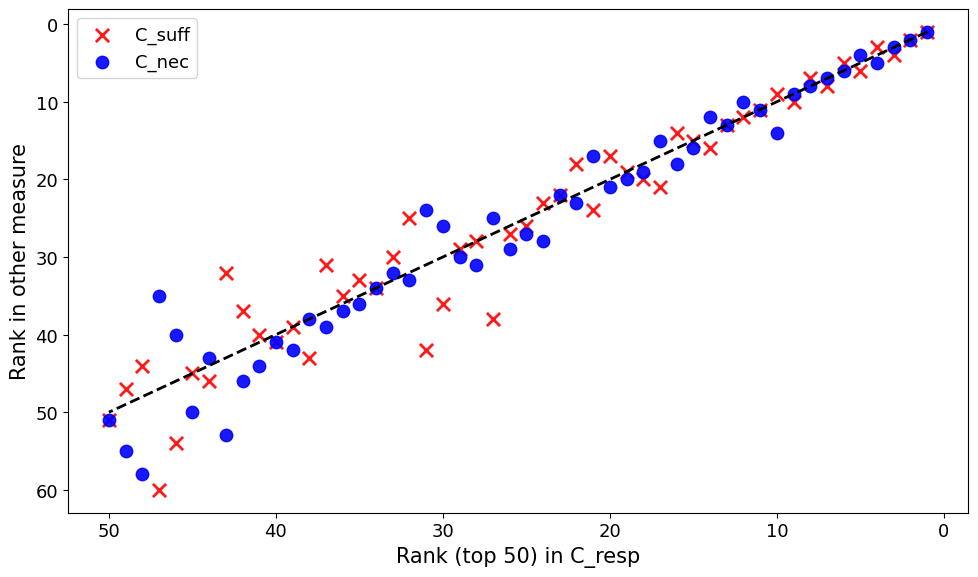


--- Spearman (rank) correlation matrix ---
           C_resp  C_suff  C_nec  C_weights
C_resp       1.00    0.96   0.98       0.96
C_suff       0.96    1.00   0.89       1.00
C_nec        0.98    0.89   1.00       0.89
C_weights    0.96    1.00   0.89       1.00


In [3]:
# =========================================================
# DROP-IN REPLACEMENT FOR YOUR *SECOND* CELL (SELF-CONTAINED)
# - RAW C_resp baseline
# - Different marker SHAPES to handle overlap: x / o / s
# - Different colours: red / blue / gold
# - No marker edge outlines
# - Black dashed diagonal
# =========================================================

from typing import Any, Dict, List, Optional

import pandas as pd
import matplotlib.pyplot as plt
from gmpy2 import mpq

# -----------------------------
# Global plot style (FONT SIZES)
# -----------------------------
BASE_FONT = 14
plt.rcParams.update({
    "font.size": BASE_FONT,
    "axes.titlesize": BASE_FONT + 2,
    "axes.labelsize": BASE_FONT + 1,
    "xtick.labelsize": BASE_FONT - 1,
    "ytick.labelsize": BASE_FONT - 1,
    "legend.fontsize": BASE_FONT - 1,
})

# -----------------------------
# Styles (3 distinct series)
# -----------------------------
SERIES_STYLES = [
    {"color": "red", "marker": "x"},
    {"color": "blue", "marker": "o"},
    {"color": "gold", "marker": "s"},
]

# -----------------------------
# Helpers: ranking
# -----------------------------
def rank_dict(measure: Dict[Any, mpq], top_n: Optional[int] = None) -> Dict[int, Any]:
    items = list(measure.items())
    items.sort(key=lambda kv: (-kv[1], str(kv[0])))
    if top_n is not None:
        items = items[:top_n]
    return {i + 1: items[i][0] for i in range(len(items))}


def rank_pos_map(measure: Dict[Any, mpq]) -> Dict[Any, int]:
    items = list(measure.items())
    items.sort(key=lambda kv: (-kv[1], str(kv[0])))
    return {items[i][0]: i + 1 for i in range(len(items))}


def c_resp_pct(c_resp: Dict[Any, mpq], total_spread: mpq) -> Dict[Any, mpq]:
    if total_spread <= 0:
        return {k: mpq(0) for k in c_resp.keys()}
    return {k: (mpq(100) * v) / total_spread for k, v in c_resp.items()}


def build_rankings_from_scores(
    summary,
    scores: Dict[str, Dict[Any, mpq]],
    top_n: int = 50,
) -> Dict[str, Dict[int, Any]]:
    resp = scores["C_resp"]
    resp_pct_map = c_resp_pct(resp, summary.total_spread)

    return {
        "C_resp": rank_dict(resp, top_n=top_n),
        "C_resp_pct": rank_dict(resp_pct_map, top_n=top_n),
        "C_suff": rank_dict(scores["C_suff"], top_n=top_n),
        "C_nec": rank_dict(scores["C_nec"], top_n=top_n),
        "C_weights": rank_dict(scores["C_weights"], top_n=top_n),
    }


def build_rank_dataframe(rankings: Dict[str, Dict[int, Any]], top_n: int) -> pd.DataFrame:
    return pd.DataFrame(
        {name: [ranking.get(r, None) for r in range(1, top_n + 1)] for name, ranking in rankings.items()},
        index=list(range(1, top_n + 1)),
    )


def plot_rank_scatter_from_scores(
    summary,
    scores: Dict[str, Dict[Any, mpq]],
    base_measure: str = "C_resp",
    compare_measures: Optional[List[str]] = None,
    top_n: int = 50,
    png_path: str = "rank_agreement_scatter.png",
    add_title: bool = False,
) -> None:
    measures: Dict[str, Dict[Any, mpq]] = {
        "C_resp": scores["C_resp"],
        "C_suff": scores["C_suff"],
        "C_nec": scores["C_nec"],
    }

    if compare_measures is None:
        compare_measures = [m for m in measures.keys() if m != base_measure]

    base_items = list(measures[base_measure].items())
    base_items.sort(key=lambda kv: (-kv[1], str(kv[0])))
    base_users = [u for u, _ in base_items[:top_n]]
    base_pos = {base_users[i]: i + 1 for i in range(len(base_users))}

    plt.figure(figsize=(10, 6))

    for idx, m in enumerate(compare_measures):
        style = SERIES_STYLES[idx % len(SERIES_STYLES)]
        y_pos = rank_pos_map(measures[m])

        xs, ys = [], []
        for u in base_users:
            if u in y_pos:
                xs.append(base_pos[u])
                ys.append(y_pos[u])

        if not xs:
            continue

        # 'x' doesn't support linewidth via scatter edge, so set linewidths directly
        if style["marker"] == "x":
            plt.scatter(
                xs, ys,
                label=m,
                alpha=0.9,
                s=90,
                marker=style["marker"],
                color=style["color"],
                linewidths=2.0,
            )
        else:
            plt.scatter(
                xs, ys,
                label=m,
                alpha=0.9,
                s=80,
                marker=style["marker"],
                color=style["color"],
            )

    # black dashed diagonal
    plt.plot([1, top_n], [1, top_n], color="black", linestyle="--", linewidth=2)

    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()

    plt.xlabel(f"Rank (top {top_n}) in {base_measure}")
    plt.ylabel("Rank in other measure")

    if add_title:
        plt.title("Rank agreement against baseline measures")

    plt.legend()
    plt.tight_layout()
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()


def spearman_rank_corr_from_scores(
    summary,
    scores: Dict[str, Dict[Any, mpq]],
    measures: Optional[List[str]] = None,
    top_n: Optional[int] = None,
) -> pd.DataFrame:
    measures_map: Dict[str, Dict[Any, mpq]] = {
        "C_resp": scores["C_resp"],
        "C_suff": scores["C_suff"],
        "C_nec": scores["C_nec"],
        "C_weights": scores["C_weights"],
    }

    if measures is None:
        measures = list(measures_map.keys())

    if top_n is None:
        users = set()
        for m in measures:
            users |= set(measures_map[m].keys())
        users = sorted(users, key=str)
    else:
        users = set()
        for m in measures:
            users |= set(rank_dict(measures_map[m], top_n=top_n).values())
        users = sorted(users, key=str)

    pos_maps = {m: rank_pos_map(measures_map[m]) for m in measures}

    df = pd.DataFrame(
        {m: [pos_maps[m].get(u, None) for u in users] for m in measures},
        index=users,
    ).dropna()

    return df.corr(method="pearson")


# =========================================================
# RUN
# =========================================================
TOP_N = 50

rankings = build_rankings_from_scores(summary, scores, top_n=TOP_N)

for name, rdict in rankings.items():
    print(name, {k: rdict[k] for k in range(1, min(11, len(rdict) + 1))})

df_ranks = build_rank_dataframe(rankings, top_n=TOP_N)
print("\n--- Rank table (rows=ranks, cols=measures) ---")
print(df_ranks.head(20))

plot_rank_scatter_from_scores(
    summary,
    scores,
    base_measure="C_resp",
    top_n=TOP_N,
    png_path="rank_agreement_scatter.png",
    add_title=False,
)

corr = spearman_rank_corr_from_scores(summary, scores, top_n=200)
print("\n--- Spearman (rank) correlation matrix ---")
print(corr)


## 4. Top-$10$ rank–score comparison (analyst view)

This cell produces a **compact comparative table** for the top-$10$ sources, showing both **rank positions** and **raw scores** across all measures.

### Purpose

The objective is to enable **fine-grained inspection** of how the same sources are evaluated under different responsibility notions.

Rather than only comparing rankings or aggregates, this view exposes:

- absolute magnitude (scores)
- relative importance (ranks)
- proportional contribution (percent of total spread)

This is the most interpretable “analyst-facing” summary of the results.

### Selection of sources

The table includes the top-$10$ sources ranked by:

$$
C_{\mathrm{resp}}(s) / v(A)
$$

i.e. **percentage contribution to total spread**, with ties broken by:

1. raw $C_{\mathrm{resp}}(s)$
2. source identifier (deterministic ordering)

This ensures the table focuses on the most globally influential sources.

### What is computed

For each selected source $s$, the following are reported:

- **Shapley responsibility**
  - `resp_rank`: rank under $C_{\mathrm{resp}}$
  - `resp_score`: raw Shapley value
  - `resp_pct`: percentage of total spread
    $$
    100 \cdot \frac{C_{\mathrm{resp}}(s)}{v(A)}
    $$

- **Sufficiency**
  - `suff_rank`, `suff_score`

- **Necessity**
  - `nec_rank`, `nec_score`

- **Weight baseline**
  - `w_rank`, `w_score`

All rankings are:

- computed using exact arithmetic (mpq)
- dense (1, 2, 3, …)
- deterministically tie-broken

### Output

The result is a DataFrame where each row corresponds to a source and columns group:

- rank (position under each measure)
- score (magnitude under each measure)

Rows are sorted by:

1. decreasing `resp_pct`
2. decreasing `resp_score`

This table makes discrepancies immediately visible, for example:

- sources with high weight but low Shapley responsibility
- sources that are sufficient but not necessary
- sources whose rank shifts significantly across measures

### Interpretation

Key patterns to look for:

- **rank stability**: agreement across columns indicates consistent attribution
- **magnitude gaps**: large score differences despite similar ranks indicate scaling effects
- **measure divergence**: rank inversions highlight structural differences between definitions

This table complements the global diagnostics (scatter + correlations) with a **local, source-level comparison**.

In [4]:
# =========================================================
# Top-10 "rank + score pairs" per measure (analyst view)
#   Assumes you already have:
#     - summary  (has .total_spread)
#     - scores   dict with keys: "C_resp", "C_suff", "C_nec", "C_weights"
#   Output:
#     DataFrame with columns:
#       user,
#       resp_rank, resp_score, resp_pct,
#       suff_rank, suff_score,
#       nec_rank,  nec_score,
#       w_rank,    w_score
# =========================================================

from typing import Any, Dict
import pandas as pd
from gmpy2 import mpq


def _ensure_mpq(x: Any) -> mpq:
    return x if isinstance(x, mpq) else mpq(str(x))


def build_rank_map(score_map: Dict[Any, mpq]) -> Dict[Any, int]:
    """
    Dense ranks: 1,2,3,... (ties broken deterministically by key string)
    Ranking uses exact mpq, not float.
    """
    ordered = sorted(score_map.items(), key=lambda kv: (-kv[1], str(kv[0])))
    rank = {}
    r = 1
    for k, _ in ordered:
        rank[k] = r
        r += 1
    return rank


def build_top10_rank_score_pairs(
    summary,
    scores: Dict[str, Dict[Any, mpq]],
    top_n: int = 10,
) -> pd.DataFrame:
    required = ["C_resp", "C_suff", "C_nec", "C_weights"]
    missing = [k for k in required if k not in scores]
    if missing:
        raise ValueError(f"scores missing keys: {missing}. Required: {required}")

    total_spread = getattr(summary, "total_spread", None)
    if total_spread is None:
        raise ValueError("summary must have attribute .total_spread")
    total_spread = _ensure_mpq(total_spread)

    resp = scores["C_resp"]
    suff = scores["C_suff"]
    nec = scores["C_nec"]
    wts = scores["C_weights"]

    # Compute resp % over *all sources* (exact), then float for display
    if total_spread > 0:
        resp_pct = {k: (mpq(100) * v) / total_spread for k, v in resp.items()}
    else:
        resp_pct = {k: mpq(0) for k in resp.keys()}

    # Rank maps for each measure
    resp_rank = build_rank_map(resp)
    suff_rank = build_rank_map(suff)
    nec_rank = build_rank_map(nec)
    w_rank = build_rank_map(wts)

    # Choose the 10 users to show: top 10 by C_resp (%) (ties broken by C_resp, then key)
    all_users = set(resp) | set(suff) | set(nec) | set(wts)
    ordered_users = sorted(
        all_users,
        key=lambda u: (
            -(resp_pct.get(u, mpq(0))),
            -(resp.get(u, mpq(0))),
            str(u),
        ),
    )[:top_n]

    rows = []
    for u in ordered_users:
        rows.append(
            {
                "user": u,

                "resp_rank": resp_rank.get(u, None),
                "resp_score": float(resp.get(u, mpq(0))),
                "resp_pct": float(resp_pct.get(u, mpq(0))),

                "suff_rank": suff_rank.get(u, None),
                "suff_score": float(suff.get(u, mpq(0))),

                "nec_rank": nec_rank.get(u, None),
                "nec_score": float(nec.get(u, mpq(0))),

                "w_rank": w_rank.get(u, None),
                "w_score": float(wts.get(u, mpq(0))),
            }
        )

    df = pd.DataFrame(rows)

    # Make it look "analyst-y": sort by resp_pct descending, then resp_score
    df = df.sort_values(["resp_pct", "resp_score"], ascending=[False, False]).reset_index(drop=True)

    # Pretty display formatting
    pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

    return df


# ---------------------------------------------------------
# Use
# ---------------------------------------------------------
df_pairs = build_top10_rank_score_pairs(summary=summary, scores=scores, top_n=10)
df_pairs


,user,resp_rank,resp_score,resp_pct,suff_rank,suff_score,nec_rank,nec_score,w_rank,w_score
0,51591,1,"14,589.05",21.21,1,"17,128.59",1,"12,558.27",1,"20,404.41"
1,27011,2,"1,854.73",2.70,2,"2,466.41",2,"1,510.18",2,"2,594.87"
2,143876,3,"1,115.59",1.62,4,"1,508.29",3,900.74,4,"1,558.00"
3,93248,4,"1,102.00",1.60,3,"1,550.25",5,873.48,3,"1,614.36"
4,143737,5,968.24,1.41,6,"1,091.15",4,890.05,6,"1,125.40"
5,9225,6,884.88,1.29,5,"1,193.99",6,718.33,5,"1,281.56"
6,95758,7,830.33,1.21,8,"1,029.23",7,708.01,8,"1,055.01"
7,92676,8,772.17,1.12,7,"1,076.66",8,614.61,7,"1,123.58"
8,141002,9,651.29,0.95,10,850.92,9,541.31,10,864.42
9,60201,10,630.43,0.92,9,908.34,14,485.28,9,964.14


## 5. Rank-Biased Overlap (RBO) between measures

This cell compares the **ranked source lists** produced by different responsibility measures using **Rank-Biased Overlap (RBO)**.

### Purpose

The earlier scatter plots and correlation matrices compare rankings position-by-position.  
This cell instead measures the **overall similarity of ranked lists**, with particular emphasis on the **top of the ranking**.

This is useful because, in practice, disagreement among the highest-ranked sources matters more than disagreement deep in the tail.

### What RBO measures

Given two ranked lists, RBO assigns a similarity score in $[0,1]$:

- **1** means the rankings are identical
- **0** means there is no overlap

Unlike ordinary rank correlation, RBO is designed for ranked lists where:

- top positions matter more than lower positions
- list overlap can vary by depth
- partial agreement near the top should be weighted more heavily

The parameter $p \in (0,1)$ controls how top-weighted the comparison is:

- lower $p$ places more weight on the very top ranks
- higher $p$ spreads weight further down the list

Here, the default is:

$$
p = 0.9
$$

which gives a strong but not exclusive emphasis to the top of the ranking.

### What the cell does

For each measure in `scores`:

1. builds a ranked list of sources by decreasing score
2. compares every pair of rankings using RBO
3. returns a table of pairwise similarity values

If `top_k=None`, the comparison uses the **full ranking** of all sources.  
If `top_k` is set, only the first $k$ ranked sources are compared.

### Output

The output DataFrame `df_rbo` contains:

- `Measure A`
- `Measure B`
- `RBO`
- `p`
- `top_k`

and is sorted by decreasing RBO.

### Interpretation

Higher RBO values indicate greater practical agreement between two measures, especially at the top of the ranked list.

This provides a complementary diagnostic to:

- scatter plots of rank agreement
- Spearman-style rank correlations

In particular:

- two measures may have high global correlation but lower top-weighted agreement
- conversely, two measures may agree strongly on the most important sources even if they diverge further down the ranking

This cell therefore captures **top-weighted ranking similarity** across the responsibility measures.

In [5]:
import numpy as np
import pandas as pd
from itertools import combinations
from typing import Dict, Any, List, Optional


# ============================================================
# Rank-Biased Overlap (RBO)
# ============================================================
def rbo(rank_a: List[Any], rank_b: List[Any], p: float = 0.9) -> float:
    S, T = rank_a, rank_b
    k = max(len(S), len(T))
    s_set, t_set = set(), set()
    summation = 0.0

    for d in range(1, k + 1):
        if d <= len(S):
            s_set.add(S[d - 1])
        if d <= len(T):
            t_set.add(T[d - 1])

        overlap = len(s_set & t_set)
        summation += (overlap / d) * (p ** (d - 1))

    return (1 - p) * summation


# ============================================================
# Helpers
# ============================================================
def build_ranking(score_dict: Dict[Any, float]) -> List[Any]:
    return [k for k, _ in sorted(score_dict.items(), key=lambda kv: kv[1], reverse=True)]


# ============================================================
# Main comparison (ALL ranks if top_k=None)
# ============================================================
def compare_rankings_top_weighted(
    scores: Dict[str, Dict[Any, float]],
    p: float = 0.9,
    top_k: Optional[int] = None,   # None => compare ALL
) -> pd.DataFrame:

    if top_k is None:
        rankings = {name: build_ranking(m) for name, m in scores.items()}
    else:
        top_k = int(top_k)
        rankings = {name: build_ranking(m)[:top_k] for name, m in scores.items()}

    rows = []
    for a, b in combinations(rankings.keys(), 2):
        ra, rb = rankings[a], rankings[b]
        val = rbo(ra, rb, p=p)
        rows.append({"Measure A": a, "Measure B": b, "RBO": val, "p": p, "top_k": top_k})

    return pd.DataFrame(rows)


if "scores" not in globals():
    raise NameError(
        "You must define `scores` as a dict mapping measure name -> {source: score}.\n"
        "See the USER INPUT SECTION in this cell."
    )


# ============================================================
# === RUN ===
# ============================================================
df_rbo = compare_rankings_top_weighted(
    scores,
    p=0.9,
    top_k=None,   # compare ALL ranks (no truncation)
)

print("\n--- Rank-Biased Overlap (top-weighted ranking similarity; ALL ranks) ---")
display(df_rbo.sort_values("RBO", ascending=False))



--- Rank-Biased Overlap (top-weighted ranking similarity; ALL ranks) ---


,Measure A,Measure B,RBO,p,top_k
4,C_suff,C_weights,0.99,0.90,None
1,C_resp,C_nec,0.96,0.90,None
0,C_resp,C_suff,0.93,0.90,None
2,C_resp,C_weights,0.93,0.90,None
3,C_suff,C_nec,0.89,0.90,None
5,C_nec,C_weights,0.89,0.90,None


## 6. Operational network of significantly responsible sources

This section constructs and visualises the **operational network** induced by the most responsible sources under $C_{\mathrm{resp}}$.

### Purpose

The goal is to move beyond individual source scores and examine how the most responsible actors are connected to one another through reposting structure.

The procedure has two stages:

1. compute each source’s percentage responsibility
2. build an induced network on the subset of sources whose responsibility exceeds a chosen significance threshold

This yields a compact graph of the most operationally important sources.

### Step 1: Convert global responsibility to percentages

The Shapley responsibility scores in `scores["C_resp"]` are first normalised to percentages:

$$
C_{\mathrm{resp}\%}(s) = 100 \cdot \frac{C_{\mathrm{resp}}(s)}{\sum_{s'} C_{\mathrm{resp}}(s')}
$$

The resulting dictionary `c_resp_pct` maps each source to its percentage share of total responsibility, and `c_resp_pct_ordered` stores the same scores sorted in descending order.

### Step 2: Build the operational network edge table

The function `operational_network_df(...)` constructs an edge table for the significant-source subgraph.

It performs the following operations:

1. retains only sources with
   $$
   C_{\mathrm{resp}\%}(s) \geq \texttt{sig\_pct}
   $$
   where the default threshold is $1.0\%$

2. takes the subgraph of `G` induced by those sources

3. removes:
   - self-loops
   - edges with non-positive weight

4. aggregates parallel edges by summing their weights

The result is a DataFrame `df_op` with one row per directed source-to-source connection, including:

- `source`
- `target`
- `weight_sum`
- `source_resp_pct`

This table is sorted by decreasing source responsibility and then edge weight.

### Step 3: Visualise the operational network

The function `draw_df_op_graphviz_simple(...)` turns `df_op` into an undirected Graphviz plot.

Key design choices:

- one edge is drawn for each unordered pair $\{u,v\}$
- if both directions are present, their weights are summed
- node **area** is proportional to `source_resp_pct`
- edge thickness is proportional to aggregated `weight_sum`
- edges are drawn as straight lines
- labels are source identifiers

Thus:

- larger nodes correspond to more responsible sources
- thicker edges indicate stronger interaction between significant sources

### Interpretation

This graph is intended to reveal whether the highest-responsibility sources operate:

- largely independently, as isolated hubs, or
- as a connected operational core with repeated inter-source interactions

In the paper, this supports the qualitative analysis of how the most responsible actors are structurally related to one another.

### Outputs

Running these cells produces:

- `c_resp_pct`: source-level percentage responsibility
- `df_op`: operational-network edge table
- a Graphviz PNG showing the induced significant-source network

This is the main network-structure visualisation associated with the global responsibility analysis.

### Installation Notes

Note you may need to additionally install the following:

conda install -c conda-forge graphviz python-graphviz

In [6]:
c_resp = scores['C_resp']

# Simple conversion: mpq -> float percentages

total = sum(c_resp.values())

c_resp_pct = {
    k: float(v / total * 100)
    for k, v in c_resp.items()
}

c_resp_pct_ordered = dict(
    sorted(c_resp_pct.items(), key=lambda kv: kv[1], reverse=True)
)


In [7]:
import pandas as pd
import networkx as nx
from typing import Dict, Any


def operational_network_df(
    G: nx.MultiDiGraph,
    c_resp_pct: Dict[Any, float],
    sig_pct: float = 1.0,
    weight_attr: str = "weight",
) -> pd.DataFrame:
    """
    Build an 'operational network' edge table.

    Steps:
      1) keep sources with resp_pct >= sig_pct
      2) take the induced subgraph of G on those sources
      3) aggregate parallel edges by SUM(weight_attr), drop self-loops / non-positive weights
      4) return DataFrame sorted by source_resp_pct desc
    """
    resp = pd.Series({str(k): float(v) for k, v in c_resp_pct.items()})
    keep = set(resp[resp >= float(sig_pct)].index)

    rows = []
    for u, v, d in G.subgraph(keep).edges(data=True):
        if u == v:
            continue
        w = float(d.get(weight_attr, 0.0))
        if w <= 0:
            continue
        rows.append((str(u), str(v), w))

    df = (
        pd.DataFrame(rows, columns=["source", "target", "weight"])
        .groupby(["source", "target"], as_index=False)
        .agg(weight_sum=("weight", "sum"))
    )

    df["source_resp_pct"] = df["source"].map(resp).astype(float)

    return df.sort_values(
        ["source_resp_pct", "weight_sum"],
        ascending=[False, False],
    ).reset_index(drop=True)

df_op = operational_network_df(G, c_resp_pct, sig_pct=1.0)
print(df_op)


    source  target  weight_sum  source_resp_pct
0    51591   92676        5.55            21.21
1    51591  143876        4.90            21.21
2    51591   95758        2.39            21.21
3    51591    9225        1.95            21.21
4    51591   93248        0.80            21.21
5    51591   27011        0.34            21.21
6    27011   51591        5.59             2.70
7    27011    9225        1.01             2.70
8    27011   95758        0.50             2.70
9    27011  143737        0.32             2.70
10  143876   51591        2.04             1.62
11  143876    9225        0.43             1.62
12  143876   27011        0.19             1.62
13  143876   93248        0.19             1.62
14   93248   51591        2.82             1.60
15   93248    9225        0.56             1.60
16   93248   92676        0.56             1.60
17    9225  143737        0.57             1.29
18    9225   27011        0.29             1.29
19   92676   51591        1.76          

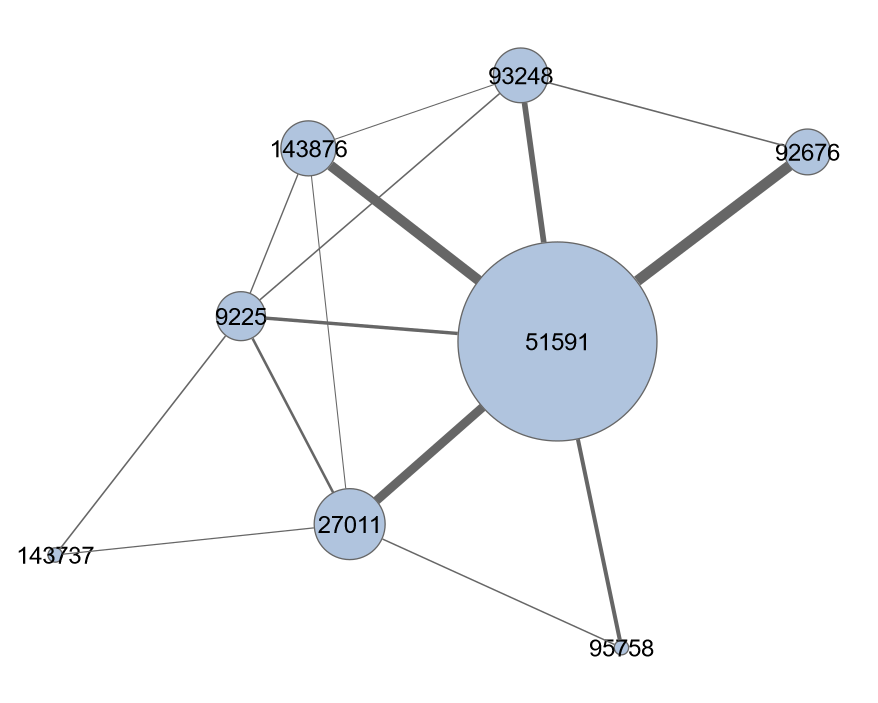

In [8]:
import math
import pandas as pd
from graphviz import Graph
from IPython.display import Image, display


def draw_df_op_graphviz_simple(
    df_op: pd.DataFrame,
    out_basename: str = "df_op_gv",
    base_node_diam_in: float = 0.45,      # node diameter (inches) at 1% resp
    edge_penwidth_range=(0.8, 8.0),       # stroke range for edges
    node_fontsize: int = 18,
) -> None:
    """
    Undirected Graphviz plot:
    - one edge per unordered pair {u,v}
    - edge weight = sum of weight_sum over both directions and duplicates
    - straight edges
    - node AREA ∝ source_resp_pct
    """

    req = {"source", "target", "weight_sum", "source_resp_pct"}
    miss = req - set(df_op.columns)
    if miss:
        raise ValueError(f"Missing columns: {sorted(miss)}")

    df = df_op.copy()
    df["source"] = df["source"].astype(str)
    df["target"] = df["target"].astype(str)
    df["weight_sum"] = pd.to_numeric(df["weight_sum"], errors="coerce").fillna(0.0)
    df["source_resp_pct"] = pd.to_numeric(df["source_resp_pct"], errors="coerce").fillna(0.0)

    # Nodes and responsibility map
    nodes = sorted(set(df["source"]) | set(df["target"]))
    resp_map = (
        df[["source", "source_resp_pct"]]
        .drop_duplicates(subset=["source"])
        .set_index("source")["source_resp_pct"]
        .to_dict()
    )

    # Undirected edge aggregation
    df["u"] = df[["source", "target"]].min(axis=1)
    df["v"] = df[["source", "target"]].max(axis=1)
    df_agg = df.groupby(["u", "v"], as_index=False)["weight_sum"].sum()

    # Edge scaling
    wvals = df_agg["weight_sum"].tolist()
    wmin, wmax = (min(wvals), max(wvals)) if wvals else (0.0, 1.0)

    def scale(x, lo, hi):
        if wmax == wmin:
            return 0.5 * (lo + hi)
        return lo + (x - wmin) * (hi - lo) / (wmax - wmin)

    # Graphviz graph
    g = Graph(engine="neato")
    g.attr(overlap="false", splines="false", pad="0.5")  # pad prevents label clipping

    g.attr(
        "node",
        shape="circle",
        style="filled",
        fillcolor="lightsteelblue",
        color="gray40",
        fontname="Arial",
        fontsize=str(node_fontsize),
    )
    g.attr("edge", color="gray40")

    # Nodes (area ∝ resp_pct ⇒ diameter ∝ sqrt(resp_pct))
    for n in nodes:
        r = float(resp_map.get(n, 0.0))
        diam = base_node_diam_in * math.sqrt(max(r, 0.0) / 1.0)
        diam = max(diam, 0.15)  # floor so 0s don't vanish
        g.node(
            n,
            label=n,
            width=f"{diam:.3f}",
            height=f"{diam:.3f}",
            fixedsize="true",
        )

    # Edges
    for u, v, ws in df_agg.itertuples(index=False):
        pen = scale(float(ws), edge_penwidth_range[0], edge_penwidth_range[1])
        g.edge(str(u), str(v), penwidth=f"{pen:.3f}")

    png_path = g.render(out_basename, format="png", cleanup=True)
    display(Image(filename=png_path))


# ----------------
# USAGE
# ----------------
draw_df_op_graphviz_simple(df_op, out_basename="df_op_gv", base_node_diam_in=0.45, node_fontsize=18)
